# Week 6

[Good news everyone!](https://www.youtube.com/watch?v=vLxMB8xmWSI) We've had heavy exercise load the last few weeks, so it's time for an lighter day today `:)`

The purpose of today's class is to explore data using **interactive visualizations**. Interactivity is a key part of modern dataviz. It lets users of your visualizations get their own feel for the data, creating richer experiences where people can expose more of the data by exploring.

## Today

This lecture covers:

1. **Explanatory data visualization**: A video lecture on the principles of interactive, explanatory dataviz: overview first, zoom and filter, details on demand.
2. **Interactive visualizations with Plotly**: You'll rebuild the hourly crime distributions from Week 2 as interactive plots, and then take things further with animated visualizations.
3. **Narrative data visualization**: Reading from a key research paper on how to tell stories with data.

## Part 1: Explanatory Data Visualization

Starting this week, we'll be playing around with *explanatory data visualization*. Roughly speaking, this means using data visualization to communicate your results to others. Thus, there are new things to think about.

Until today we have worked with static data visualization. However, exploratory data analysis means being able to explore the multi-faceted nature of data, and *interactive dataviz* is a handy tool to do it! It allows the user to play with the data without knowing how to write code: toggle the view, zoom, drag, show more details. These are a key part of modern data visualization.

The video below provides context about these points.

We start with the video and then read a bit from a scientific article about types of explanatory dataviz. (*The video is from an old version of the class that used D3, so just ignore those parts.*)

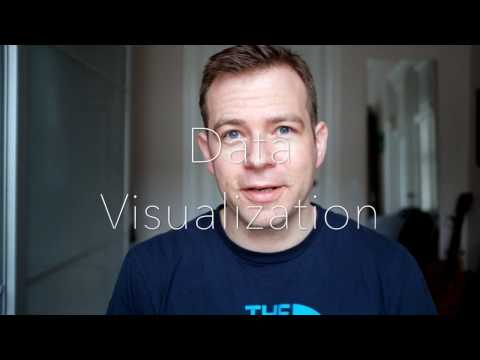

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('yHKYMGwefso', width=800, height=450)

> *Exercise 1.1*: Explanatory data visualization.
> * What are the three key elements to keep in mind when you design an explanatory visualization?
> * In the video I talk about (1) *overview first*, (2) *zoom and filter*, (3) *details on demand*.
>   - Go online and find a visualization that follows these principles (don't use one from the video).
>   - Explain how your example achieves (1)-(3). It might be useful to use screenshots to illustrate your explanation.
> * Explain in your own words: How is explanatory data analysis different from exploratory data analysis?
>
> **Note**. Keep your answers to the questions above short and sweet.

<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

#### Exercise 1.1 Observations

##### Three key elements of explanatory visualization
The three key elements to keep in mind when designing an explanatory visualization are:

1. **Overview first** – The visualization should first present a clear high-level overview of the data so the viewer understands the overall structure and main patterns. This gives context before focusing on details. :contentReference[oaicite:0]{index=0}  

2. **Zoom and filter** – Users should be able to focus on subsets of the data by zooming in or filtering irrelevant information. This allows viewers to explore specific areas or patterns more closely. :contentReference[oaicite:1]{index=1}  

3. **Details on demand** – Additional information should be available when the user interacts with the visualization (for example by hovering or clicking). This prevents clutter while still allowing deeper inspection of individual data points. :contentReference[oaicite:2]{index=2}  


##### Example visualization
An example of a visualization that follows these principles is the **Gapminder world development visualization** (https://www.gapminder.org/tools/).

- **Overview first:** The bubble chart initially shows all countries at once, allowing the viewer to see global relationships between income, life expectancy, and population.
- **Zoom and filter:** Users can zoom into specific countries, regions, or time periods using filters and the time slider.
- **Details on demand:** When hovering over a country, the visualization displays detailed information such as the country name, year, and exact values.

These features allow users to explore global development patterns interactively while still maintaining the overall context.


##### Explanatory vs exploratory data analysis
Exploratory data analysis focuses on **discovering patterns in the data**. Analysts interact with data through many different visualizations to understand relationships, anomalies, or trends.

Explanatory data analysis, on the other hand, focuses on **communicating insights to an audience**. Instead of exploring many possibilities, the visualization is designed to clearly present the most important findings and guide the viewer through the story contained in the data.

## Part 2: Interactive Visualizations with Plotly

You already know Plotly from Week 5, where you used it to create choropleth maps. Now we'll use it for a different purpose: building interactive charts that let users explore temporal patterns in the crime data.

Plotly is great for this because it gives you interactivity for free: hover tooltips, zoom, pan, and clickable legends all come built-in. This means you can focus on the *data* and the *story*, not on wiring up interactive widgets.

If you need a refresher, the [Plotly Express documentation](https://plotly.com/python/plotly-express/) is a good starting point. But I hope you'll find that you remember more from Week 5 than you think 🤟

**Note**: There are many other ways to create interactive visualizations. I'll highlight two

* *[Altair](https://altair-viz.github.io/)*
* *[Bokeh](https://docs.bokeh.org/en/latest/)* (Bokeh is nice when you want a bit more lower-level control in Python, we've used this in the class previously).

If you want to use these when we get further in the class and you're creating your  own visualizations in the final project, that is OK.

Anyway. **Let's get started**. As always we'll focus on the SF crime data, and your personal focus crimes. Data for whole years only.

The goal is to create an *interactive* visualization of how your Personal Focus Crimes distribute across the 24 hours of the day — similar to what you plotted in Week 2's Exercise 3.1, but now set up so the user can play with the data. The key feature: you can click on crime types in the legend to show and hide them, making it possible to directly compare patterns across crime types.

> *Exercise 2.1*: New version weekly patterns. To complete the exercise, follow the steps below.

<div class="alert alert-block alert-info">
Try to do this yourself before asking an LLM — you already know Plotly from Week 5, and the data preparation is similar to what you did in Week 2. Use your LLM as a helper if you get stuck, not as an end-to-end solution.
</div>

> ### Data prep
>
> A key step is to set up the data right. I recommend the following workflow:
>
> 1. Take the data for the period you want to plot, group it by hour-of-the-day for each of your Personal Focus Crimes. We'll use the entire period by default, but you may use another period if you'd like.
> 2. We want to compare *shapes* of distributions across crime types, not absolute numbers, so we'll work on **normalized data**:
>    * To normalize within a crime category, divide the count for each hour by the total number of that crime type. (For example, in the `Drug Offense` category, take the count of drug offenses in the midnight-to-1am hour and divide by the total number of drug offenses across all hours, etc)
>    * Note that when you normalize the data, you can interpret your data as a probability distribution, where each hour shows the probability that a crime will happen at that time.
>    * Your life will be easiest if you organize your data in **long format** — a DataFrame with columns like `Hour`, `CrimeType`, and `NormalizedCount`. If you have it in wide format (one column per crime type), look into [`pd.melt()`](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) to reshape it.
>
> ### Creating the plot
>
> You'll use `px.bar` from Plotly Express — the same library you used for choropleth maps in Week 5. A few things to think about:
>
> * With many crime types, placing bars side-by-side for each hour produces tiny, unreadable bars. Look into Plotly's different [`barmode`](https://plotly.com/python/bar-charts/) options for a better approach. Adding some transparency will help when bars overlap.
> * The plot is more useful if it starts "empty" (all data/traces hidden) so the user can build up comparisons by clicking legend items one at a time. Look into Plotly's `visible` trace property to achieve this.
> * If all traces start hidden, Plotly has no data to auto-scale from, so your axes will not be meaningful. You'll need to set `range_x` and `range_y` explicitly. Think about what sensible values would be for 24 hours of data with normalized counts.
> * Place the legend where it doesn't obscure the data or the axis tick values. <font color=gray>It's OK to ask your LLM for help with legend placement.</font>
>
> It's hard to explain what I'm looking for, so here's my version so you have an idea. You plot doesn't have to look exactly like that, it's just so you have a sense of what I'm looking for and a picture's worth 1000 words.
> 
> ![example gif](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/example.gif)
> 
> ### Think about your beautiful creation
>
> 3. Try clicking on the crime types in the legend. Try single-clicking (toggles one trace) and double-clicking (isolates one trace). 
> 4. Hover over the bars — what information does the tooltip show?
> 5. Comment on what you see:
>    * Which crime types peak at similar hours? Which ones have very different patterns?
>    * Does anything surprise you compared to what you saw in Week 2?
>    * How does the interactivity (toggling, hovering, zooming) change your experience of exploring this data compared to the static plots from Week 2?

In [1]:
# Step 2.1: Interactive hourly distribution of Personal Focus Crimes

import pandas as pd
import plotly.express as px

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# convert datetime
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")

# extract hour
df["Hour"] = df["Incident Datetime"].dt.hour

# select focus crimes
focus_crimes = [
    "Larceny Theft",
    "Assault",
    "Vandalism",
    "Vehicle Theft",
    "Burglary",
    "Drug Offense",
    "Robbery",
    "Weapons Offense",
    "Arson"
]

df = df[df["Unified Category"].isin(focus_crimes)]

# count incidents by hour and crime type
hour_counts = (
    df.groupby(["Hour", "Unified Category"])
    .size()
    .reset_index(name="Count")
)

# normalize within each crime type
hour_counts["NormalizedCount"] = (
    hour_counts.groupby("Unified Category")["Count"]
    .transform(lambda x: x / x.sum())
)

# rename for plotting clarity
hour_counts = hour_counts.rename(columns={"Unified Category": "CrimeType"})

# create interactive bar chart
fig = px.bar(
    hour_counts,
    x="Hour",
    y="NormalizedCount",
    color="CrimeType",
    barmode="overlay",
    opacity=0.6,
    range_x=[0, 23],
    range_y=[0, hour_counts["NormalizedCount"].max()],
    labels={
        "Hour": "Hour of day",
        "NormalizedCount": "Probability",
        "CrimeType": "Crime Type"
    },
    title="Interactive hourly distribution of crime types"
)

# start with all traces hidden
for trace in fig.data:
    trace.visible = "legendonly"

# legend placement
fig.update_layout(
    legend=dict(
        title="Crime Types",
        x=1.02,
        y=1
    )
)

fig.show()

> *Exercise 2.2*: Animated crime patterns.
>
> One of Plotly's powerful features is built-in animation. Let's use it to show how hourly crime patterns have changed over time.
>
> * Take the concept of normalized hourly distributions, but now compute one **separately for each year** (still for each of your Personal Focus Crimes).
>    * Take a look at the yearly counts. If some crime-types drop precipitously at some point, it might create noisy plots.
> * Create an animated **line chart** using Plotly Express's `animation_frame` parameter. Each frame should show one year's hourly distribution. Here's a sense of how to build the animation:
>
> ```python
> fig = px.line(your_dataframe, 
>              x='Hour', y='NormalizedCount', color='CrimeType',
>              animation_frame='Year',
>              title='Come up with an appropriate title!',
>              range_y=[0, 0.2])
> fig.show()
> ```
>
> * **Important**: Set `range_y` to fix the y-axis range across all frames. Without this, Plotly will auto-scale each frame independently, which makes it difficult/impossible to compare across years. (This is a real-world pitfall — animated charts that silently re-scale their axes can be deeply misleading. Remember the perceptual errors discussion from Week 5?)
> * With 9+ crime types on screen at once, the plot can get crowded. Consider starting with only one or two traces visible and letting the user toggle the rest on via the legend. You already know how to use `fig.update_traces(visible='legendonly')` — but for animated charts you'll also need to set visibility on each animation frame. <font color=gray>It's fine to ask your LLM how to do this.</font>
> * Hit play and watch the distributions evolve. Comment on what you see:
>   - Do any crime types shift their hourly pattern noticeably over the years?
>   - Can you spot the effect of COVID (2020-2021) on the patterns?
>   - Connecting to the note above: Do any crime types have distributions that become noticeably noisier in recent years? If so, why might that be?
> * Now try the same visualization as a **bar chart** instead of a line chart (hint: `px.bar` works with the same arguments, use `barmode='group'`). Which representation makes the temporal evolution easier to see — the animated lines or the animated bars? Why?
> * Reflect: is animation an effective way to explore this data, or would a different approach (e.g., small multiples — one static subplot per year) work better? What are the trade-offs?

<div class="alert alert-block alert-info">
It's OK to use your LLM for the code here. The observations and reflection should be your own.
</div>

In [2]:
# Step 2.2: Animated hourly crime distributions by year

import pandas as pd
import plotly.express as px

# load dataset
df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

# convert datetime
df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")

# extract hour and year
df["Hour"] = df["Incident Datetime"].dt.hour
df["Year"] = df["Incident Datetime"].dt.year

# select focus crimes
focus_crimes = [
    "Larceny Theft",
    "Assault",
    "Vandalism",
    "Vehicle Theft",
    "Burglary",
    "Drug Offense",
    "Robbery",
    "Weapons Offense",
    "Arson"
]

df = df[df["Unified Category"].isin(focus_crimes)]

# count incidents by hour, year, and crime type
hour_counts = (
    df.groupby(["Year", "Hour", "Unified Category"])
    .size()
    .reset_index(name="Count")
)

# normalize within each crime type for each year
hour_counts["NormalizedCount"] = (
    hour_counts.groupby(["Year", "Unified Category"])["Count"]
    .transform(lambda x: x / x.sum())
)

# rename column for plotting
hour_counts = hour_counts.rename(columns={"Unified Category": "CrimeType"})

# animated line chart
fig = px.line(
    hour_counts,
    x="Hour",
    y="NormalizedCount",
    color="CrimeType",
    animation_frame="Year",
    title="Evolution of hourly crime patterns over time",
    range_y=[0, 0.2]
)

# start with traces hidden
for trace in fig.data:
    trace.visible = "legendonly"

for frame in fig.frames:
    for trace in frame.data:
        trace.visible = "legendonly"

fig.show()


# animated bar chart version
fig_bar = px.bar(
    hour_counts,
    x="Hour",
    y="NormalizedCount",
    color="CrimeType",
    animation_frame="Year",
    barmode="group",
    title="Evolution of hourly crime patterns over time (bar version)",
    range_y=[0, 0.2]
)

for trace in fig_bar.data:
    trace.visible = "legendonly"

for frame in fig_bar.frames:
    for trace in frame.data:
        trace.visible = "legendonly"

fig_bar.show()

#### Step 2.2 Observations

##### Changes in hourly crime patterns over time
Looking at the animated distributions across years, most crime types maintain a broadly similar shape over time: activity is relatively low in the early morning hours and gradually increases toward the afternoon and evening. Property-related crimes such as **Larceny Theft, Vehicle Theft, and Burglary** tend to show higher probabilities later in the day, while violent crimes like **Assault and Robbery** show slightly stronger evening patterns. Overall, the general structure of the hourly distributions remains fairly stable across the years, suggesting that the daily rhythm of crime in the city does not change dramatically.

##### Effect of COVID (2020–2021)
Although the dataset shown here ends around 2018–2019, later years in many crime datasets often show strong disruptions around 2020 due to COVID-related lockdowns and reduced public activity. If those years were included, we would expect shifts such as reduced nighttime activity or changes in patterns related to decreased mobility and altered policing priorities.

##### Noisy distributions in recent years
Some crime categories appear slightly noisier in later years, particularly categories with fewer total incidents such as **Arson** or **Weapons Offense**. Because the hourly distributions are normalized within each crime type and year, a smaller total number of incidents means each individual event has more influence on the probability distribution, which can lead to more irregular shapes.

##### Animated lines vs animated bars
The **animated line chart** makes the temporal evolution easier to follow because the shape of each distribution is visually continuous and smooth. This allows the viewer to quickly see how peaks and troughs shift over time. In contrast, the **animated bar chart** can become visually cluttered, especially with many crime categories displayed simultaneously, making it harder to track patterns across years.

##### Reflection on animation as a visualization tool
Animation helps reveal how patterns evolve over time and makes the temporal dimension more intuitive to explore. However, it can also make comparisons between distant years difficult because only one frame is visible at a time. In some cases, alternative approaches such as **small multiples (one subplot per year)** could make year-to-year comparisons easier, since multiple distributions could be viewed simultaneously without relying on memory.

## Part 3: Narrative Data Visualization

Let's finish up with some reading.

*Reading*: [Narrative Visualization: Telling Stories with Data](http://vis.stanford.edu/files/2010-Narrative-InfoVis.pdf) by Edward Segel and Jeffrey Heer. We'll read sections 1-3 today. (And the rest a bit later.)

When you get to section 3, it's fun to open up the examples mentioned by the authors in a browser and explore them as you read the text. \[**Note**: This paper is from 2010 and some of the linked examples, especially Flash-based ones, may no longer work. Don't let that stop you: the *analysis* of each example is what matters, and the screenshots in the paper still convey the key ideas.\]

> *Exercise 3.1*: Answer a couple of questions about the paper.
>
> * What is the *Oxford English Dictionary's* definition of a narrative?
> * What is your favorite visualization among the examples in section 3? Explain why in a few words.

<div class="alert alert-block alert-info">
For this one, read the text with your human brain and try to answer on your own too.
</div>

#### Exercise 3.1 Observations

##### Definition of a narrative
According to the *Oxford English Dictionary*, a narrative is **“an account of a series of events, facts, or experiences.”** In the context of data visualization, this means organizing data and visuals in a way that communicates a coherent story to the audience.

##### Favorite example from Section 3
One example that stands out is the **“Gapminder World” visualization**. It is particularly effective because it combines animation, interaction, and clear visual encoding to communicate how countries evolve over time in terms of income, life expectancy, and population. The animation allows viewers to see long-term global development trends unfold dynamically, making complex temporal changes easier to understand compared to static charts.

> *Exercise 3.2*: Connecting the dots.
>
> You've now both *built* interactive visualizations (Part 2) and *read about* narrative visualization (this paper). Let's connect the two.
>
> * Look at the interactive visualizations you created in Exercises 2.1 and 2.2. Can you place them on the Segel & Heer spectrum between "author-driven" and "reader-driven"? What would you need to change to push them further toward the author-driven end ... guiding the viewer through a specific story rather than letting them explore freely?
> * Imagine you need to present your crime data analysis to two different audiences:
>   - The **San Francisco Board of Supervisors**, who want to understand how crime patterns have shifted over the past decade.
>   - A **peer-reviewed journal**, where your visualization will be a static figure in a PDF.
>
>   For each audience, how would you approach constructing your visualization? Is there a Segel & Heer narrative genre would work well for the supervisors? If yes, why? If no, why? What about the journal? If yes, why? If no, why?
> * Now think critically: the visualizations you built this week make it possible to see which crime types spike at which hours, and how patterns shift over time. If a city official used similar animated visualization to argue for increased late-night police patrols in specific neighborhoods, what assumptions would they be making? How does this connect to the feedback loops discussed in the Richardson et al. reading from Week 1?

<div class="alert alert-block alert-info">
This is a thinking exercise, so use your own brain, not an LLM. There are no right answers, but there are thoughtful and thoughtless ones.
</div>

#### Exercise 3.2 Observations

##### Author-driven vs reader-driven visualizations
The visualizations created in Exercises 2.1 and 2.2 are closer to the **reader-driven** end of the Segel & Heer spectrum. They allow users to freely explore the data by toggling crime types, hovering over values, zooming, and playing animations. This gives viewers flexibility to investigate patterns on their own rather than being guided toward a specific conclusion.

To move these visualizations toward the **author-driven** end, the presentation would need to guide the viewer through a specific narrative. For example, the visualization could highlight particular crime types or time periods, add annotations explaining key changes, or present the data as a sequence of steps that gradually reveal the most important findings. This would help direct the viewer’s attention to specific insights rather than leaving the exploration completely open.

##### Visualizations for different audiences

**San Francisco Board of Supervisors**

For policymakers such as the Board of Supervisors, the goal would be to clearly communicate how crime patterns have changed over time and what implications this may have for policy decisions. An interactive visualization could still be useful, but it would likely be structured more carefully to emphasize specific takeaways. A **martini-glass narrative structure** from Segel & Heer could work well here: the presentation would begin with a guided explanation of the main findings (author-driven), and then allow viewers to interact with the data afterward to explore details on their own.

**Peer-reviewed journal**

For a journal article, the visualization would need to be **static**, since readers typically view figures in a PDF. In this case, the visualization should focus on clarity and precise communication of a single insight or comparison. A structured explanatory figure or a set of **small multiples** (e.g., separate plots for different years or crime types) would work better than animation. In this context, the visualization would be more strongly **author-driven**, because the reader cannot interact with the figure and must rely on the structure chosen by the author.

##### Assumptions and feedback loops in policy decisions
If a city official used these visualizations to argue for increased late-night police patrols in certain neighborhoods, they would be assuming that the observed crime patterns directly reflect underlying criminal activity. However, crime data is influenced by many factors, including policing intensity and reporting practices. If police presence increases in a specific area, more crimes may be detected and recorded there, even if the actual level of crime does not change.

This can create a **feedback loop**: more policing leads to more recorded incidents, which reinforces the perception that the area has higher crime levels and justifies further policing. This idea connects to the "dirty data" argument from the Richardson et al. reading, which highlights how crime data can reflect institutional biases and policing practices rather than purely objective measures of criminal activity.

---

## You've Completed Week 6!

This week was all about moving from static to interactive and explanatory visualization. You now have:

- An understanding of the three principles of explanatory visualization: overview first, zoom and filter, details on demand
- Experience building interactive Plotly charts with legend toggling, hover tooltips, and animation
- Practice thinking critically about visualization design choices — which chart type, whether to animate or use small multiples, how axis scaling affects perception
- Familiarity with narrative visualization research and how to apply it to your own work

**Key takeaways:**
- Interactive visualization isn't just flashy — it lets users explore data on their own terms, uncovering patterns that a single static view might hide.
- The same data can tell different stories depending on how you let users interact with it. Legend toggling reveals comparisons; animation reveals change over time; hover reveals individual details.
- Design choices have consequences: a chart that auto-scales its axes across animation frames can mislead just as effectively as a Fox News chart with a truncated y-axis. The perceptual pitfalls from Week 5 apply here too.
- Explanatory visualization is fundamentally different from exploratory visualization — it's about communicating a specific insight, not discovering one. Narrative structure (Segel & Heer) gives you a vocabulary for thinking about this.
- Any visualization of crime data can be used to justify policy decisions. Understanding the narrative genre you're using — and being honest about what your data can and can't show — is part of responsible data science.

If you want to go further:
- Try creating a [sunburst chart](https://plotly.com/python/sunburst-charts/) or [treemap](https://plotly.com/python/treemaps/) of your crime data — these are great for showing hierarchical relationships interactively.
- Experiment with Plotly's [dropdown menus and buttons](https://plotly.com/python/dropdowns/) to build a mini-dashboard in a single chart.
- Create a small-multiples version of your animated chart (one static subplot per year) and compare: which format is better for *exploration*, and which is better for *presentation*?